Импорт библиотек

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import kagglehub

/home/esdeat/anaconda3/envs/tf_2.2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Скачивание датасета из Kaggl

In [3]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Path to dataset files:", path)

100%|██████████| 2.70G/2.70G [11:55<00:00, 4.05MB/s]

Extracting files...


Path to dataset files: /home/esdeat/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2


 Определяем пути к папкам train и valid внутри скачанного датасета

In [4]:
train_path = os.path.join(path, 'new plant diseases dataset(augmented)', 'New Plant Diseases Dataset(Augmented)', 'train')
valid_path = os.path.join(path, 'new plant diseases dataset(augmented)', 'New Plant Diseases Dataset(Augmented)', 'valid')

Если структура другая, можно попробовать альтернативные пути

In [5]:
if not os.path.exists(train_path):
    # Пробуем более простую структуру
    train_path = os.path.join(path, 'train')
    valid_path = os.path.join(path, 'valid')

print("Train path:", train_path)
print("Valid path:", valid_path)

Train path: /home/esdeat/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
Valid path: /home/esdeat/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid


Предобработка данных

Предобработка изображений для обучения

In [6]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


I0000 00:00:1780923516.803660  168174 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:10:00.0, compute capability: 8.9


Предобработка изображений для валидации

In [7]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

training_set

for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

Found 17572 files belonging to 38 classes.
tf.Tensor(
[[[[106.5  110.5  111.5 ]
   [106.   110.   111.  ]
   [114.75 118.75 119.75]
   ...
   [134.   138.   139.  ]
   [134.75 138.75 139.75]
   [135.25 139.25 140.25]]

  [[105.5  109.5  110.5 ]
   [101.25 105.25 106.25]
   [114.5  118.5  119.5 ]
   ...
   [131.5  135.5  136.5 ]
   [134.   138.   139.  ]
   [135.75 139.75 140.75]]

  [[ 99.75 103.75 104.75]
   [ 97.75 101.75 102.75]
   [112.   116.   117.  ]
   ...
   [129.   133.   134.  ]
   [131.5  135.5  136.5 ]
   [133.25 137.25 138.25]]

  ...

  [[ 32.75  41.75  38.75]
   [ 31.    40.    37.  ]
   [ 30.    39.    36.  ]
   ...
   [ 38.    48.    47.  ]
   [ 36.75  46.75  45.75]
   [ 33.5   43.5   42.5 ]]

  [[ 29.75  38.75  35.75]
   [ 28.    37.    34.  ]
   [ 27.    36.    33.  ]
   ...
   [ 37.    47.    46.  ]
   [ 36.    46.    45.  ]
   [ 32.75  42.75  41.75]]

  [[ 32.25  41.25  38.25]
   [ 31.    40.    37.  ]
   [ 29.75  38.75  35.75]
   ...
   [ 33.75  43.75  42.75]
   

Построение модели

In [9]:
# 1. Добавьте эти импорты (лучше всего в самую первую ячейку с импортами)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# 2. Инициализируйте пустую последовательную модель
model = Sequential()

# 3. Построение модели
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[128, 128, 3]))
model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2)) # Исправлено на MaxPooling2D

model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

model.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

model.add(Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

model.add(Dropout(0.25)) # Чтобы избежать переобучения

model.add(Flatten())
model.add(Dense(units=1500, activation='relu'))
model.add(Dropout(0.4))

# Выходной слой (38 классов для датасета New Plant Diseases Dataset)
model.add(Dense(units=38, activation='softmax'))

# Просмотр структуры модели
model.summary()

/home/esdeat/anaconda3/envs/tf_2.2/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

Компиляция модели

In [ ]:
# Компиляция модели 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Просмотр итоговой структуры модели
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

Обучение модели

In [12]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


I0000 00:00:1780923705.472019  175299 service.cc:153] XLA service 0x7a79e803c930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780923705.472054  175299 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780923705.545859  175299 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780923706.033337  175299 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780923706.121453  175299 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4434__.68
I0000 00:00:1780923708.756334  175989 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1780923721.448573  175299 device_compiler.h:208] Compiled cluster us

2195/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3909 - loss: 2.1835

I0000 00:00:1780923795.725296  175302 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4434__.68


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 116s 44ms/step - accuracy: 0.5987 - loss: 1.3752 - val_accuracy: 0.8321 - val_loss: 0.5280
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.8623 - loss: 0.4370 - val_accuracy: 0.9086 - val_loss: 0.2763
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.9153 - loss: 0.2624 - val_accuracy: 0.9263 - val_loss: 0.2216
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.9390 - loss: 0.1874 - val_accuracy: 0.9520 - val_loss: 0.1505
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.9557 - loss: 0.1348 - val_accuracy: 0.9425 - val_loss: 0.1925
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - accuracy: 0.9653 - loss: 0.1061 - val_accuracy: 0.9570 - val_loss: 0.1331
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - accuracy: 0.9713 - loss: 0.0887 - val_accuracy: 0.9373 - val_loss: 0.2213
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - accuracy: 0.9761 - loss: 0.0

Оценка модели

In [13]:
# Оценка модели на обучающей выборке
train_loss,train_acc = model.evaluate(training_set)
print(train_loss,train_acc)

# Оценка модели на валидационной выборке
val_loss,val_acc = model.evaluate(validation_set)
print(val_loss,val_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.9940 - loss: 0.0197
0.019723212346434593 0.9940109252929688
550/550 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9686 - loss: 0.1044
0.10442133247852325 0.9685863852500916


Сохранение модели

In [14]:
model.save("trained_model.keras")
training_history.history

# Сохранение истории обучения в json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

training_history.history['val_accuracy']

[0.8320623636245728,
 0.908604621887207,
 0.9263032078742981,
 0.9519690275192261,
 0.9424653053283691,
 0.9570339322090149,
 0.9372866153717041,
 0.9640336632728577,
 0.9558388590812683,
 0.9685863852500916]

Визуализация точности

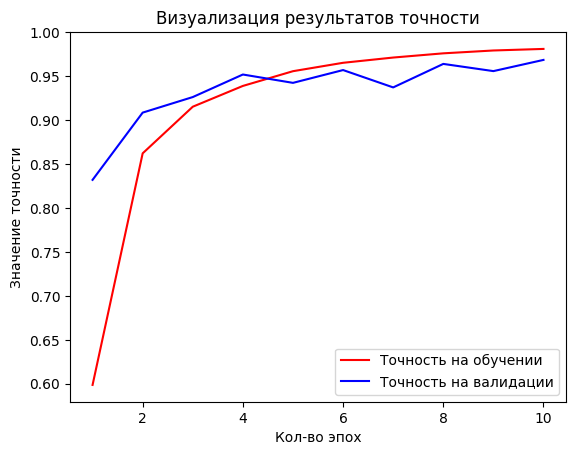

In [15]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Точность на обучении')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Точность на валидации')
plt.xlabel("Кол-во эпох")
plt.ylabel("Значение точности")
plt.title("Визуализация результатов точности")
plt.legend()
plt.show()

другие метрики для оценки модели

In [16]:
class_name = validation_set.class_names
class_name

test_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

y_pred = model.predict(test_set)
y_pred,y_pred.shape

predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

Y_true = tf.argmax(true_categories,axis=1)
Y_true

from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_true,predicted_categories,target_names=class_name))

cm = confusion_matrix(Y_true,predicted_categories)
cm

Found 17572 files belonging to 38 classes.
550/550 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.90      0.94       504
                                 Apple___Black_rot       0.95      0.99      0.97       497
                          Apple___Cedar_apple_rust       0.97      0.97      0.97       440
                                   Apple___healthy       0.97      0.98      0.97       502
                               Blueberry___healthy       0.97      0.98      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.99       421
                 Cherry_(including_sour)___healthy       0.97      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.90      0.93       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00     

array([[453,  18,   1, ...,   0,   1,   0],
       [  0, 492,   0, ...,   0,   0,   0],
       [  0,   0, 426, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 485,   0,   0],
       [  0,   0,   0, ...,   0, 444,   0],
       [  0,   0,   0, ...,   0,   0, 477]], shape=(38, 38))

Визуализация матрицы ошибок

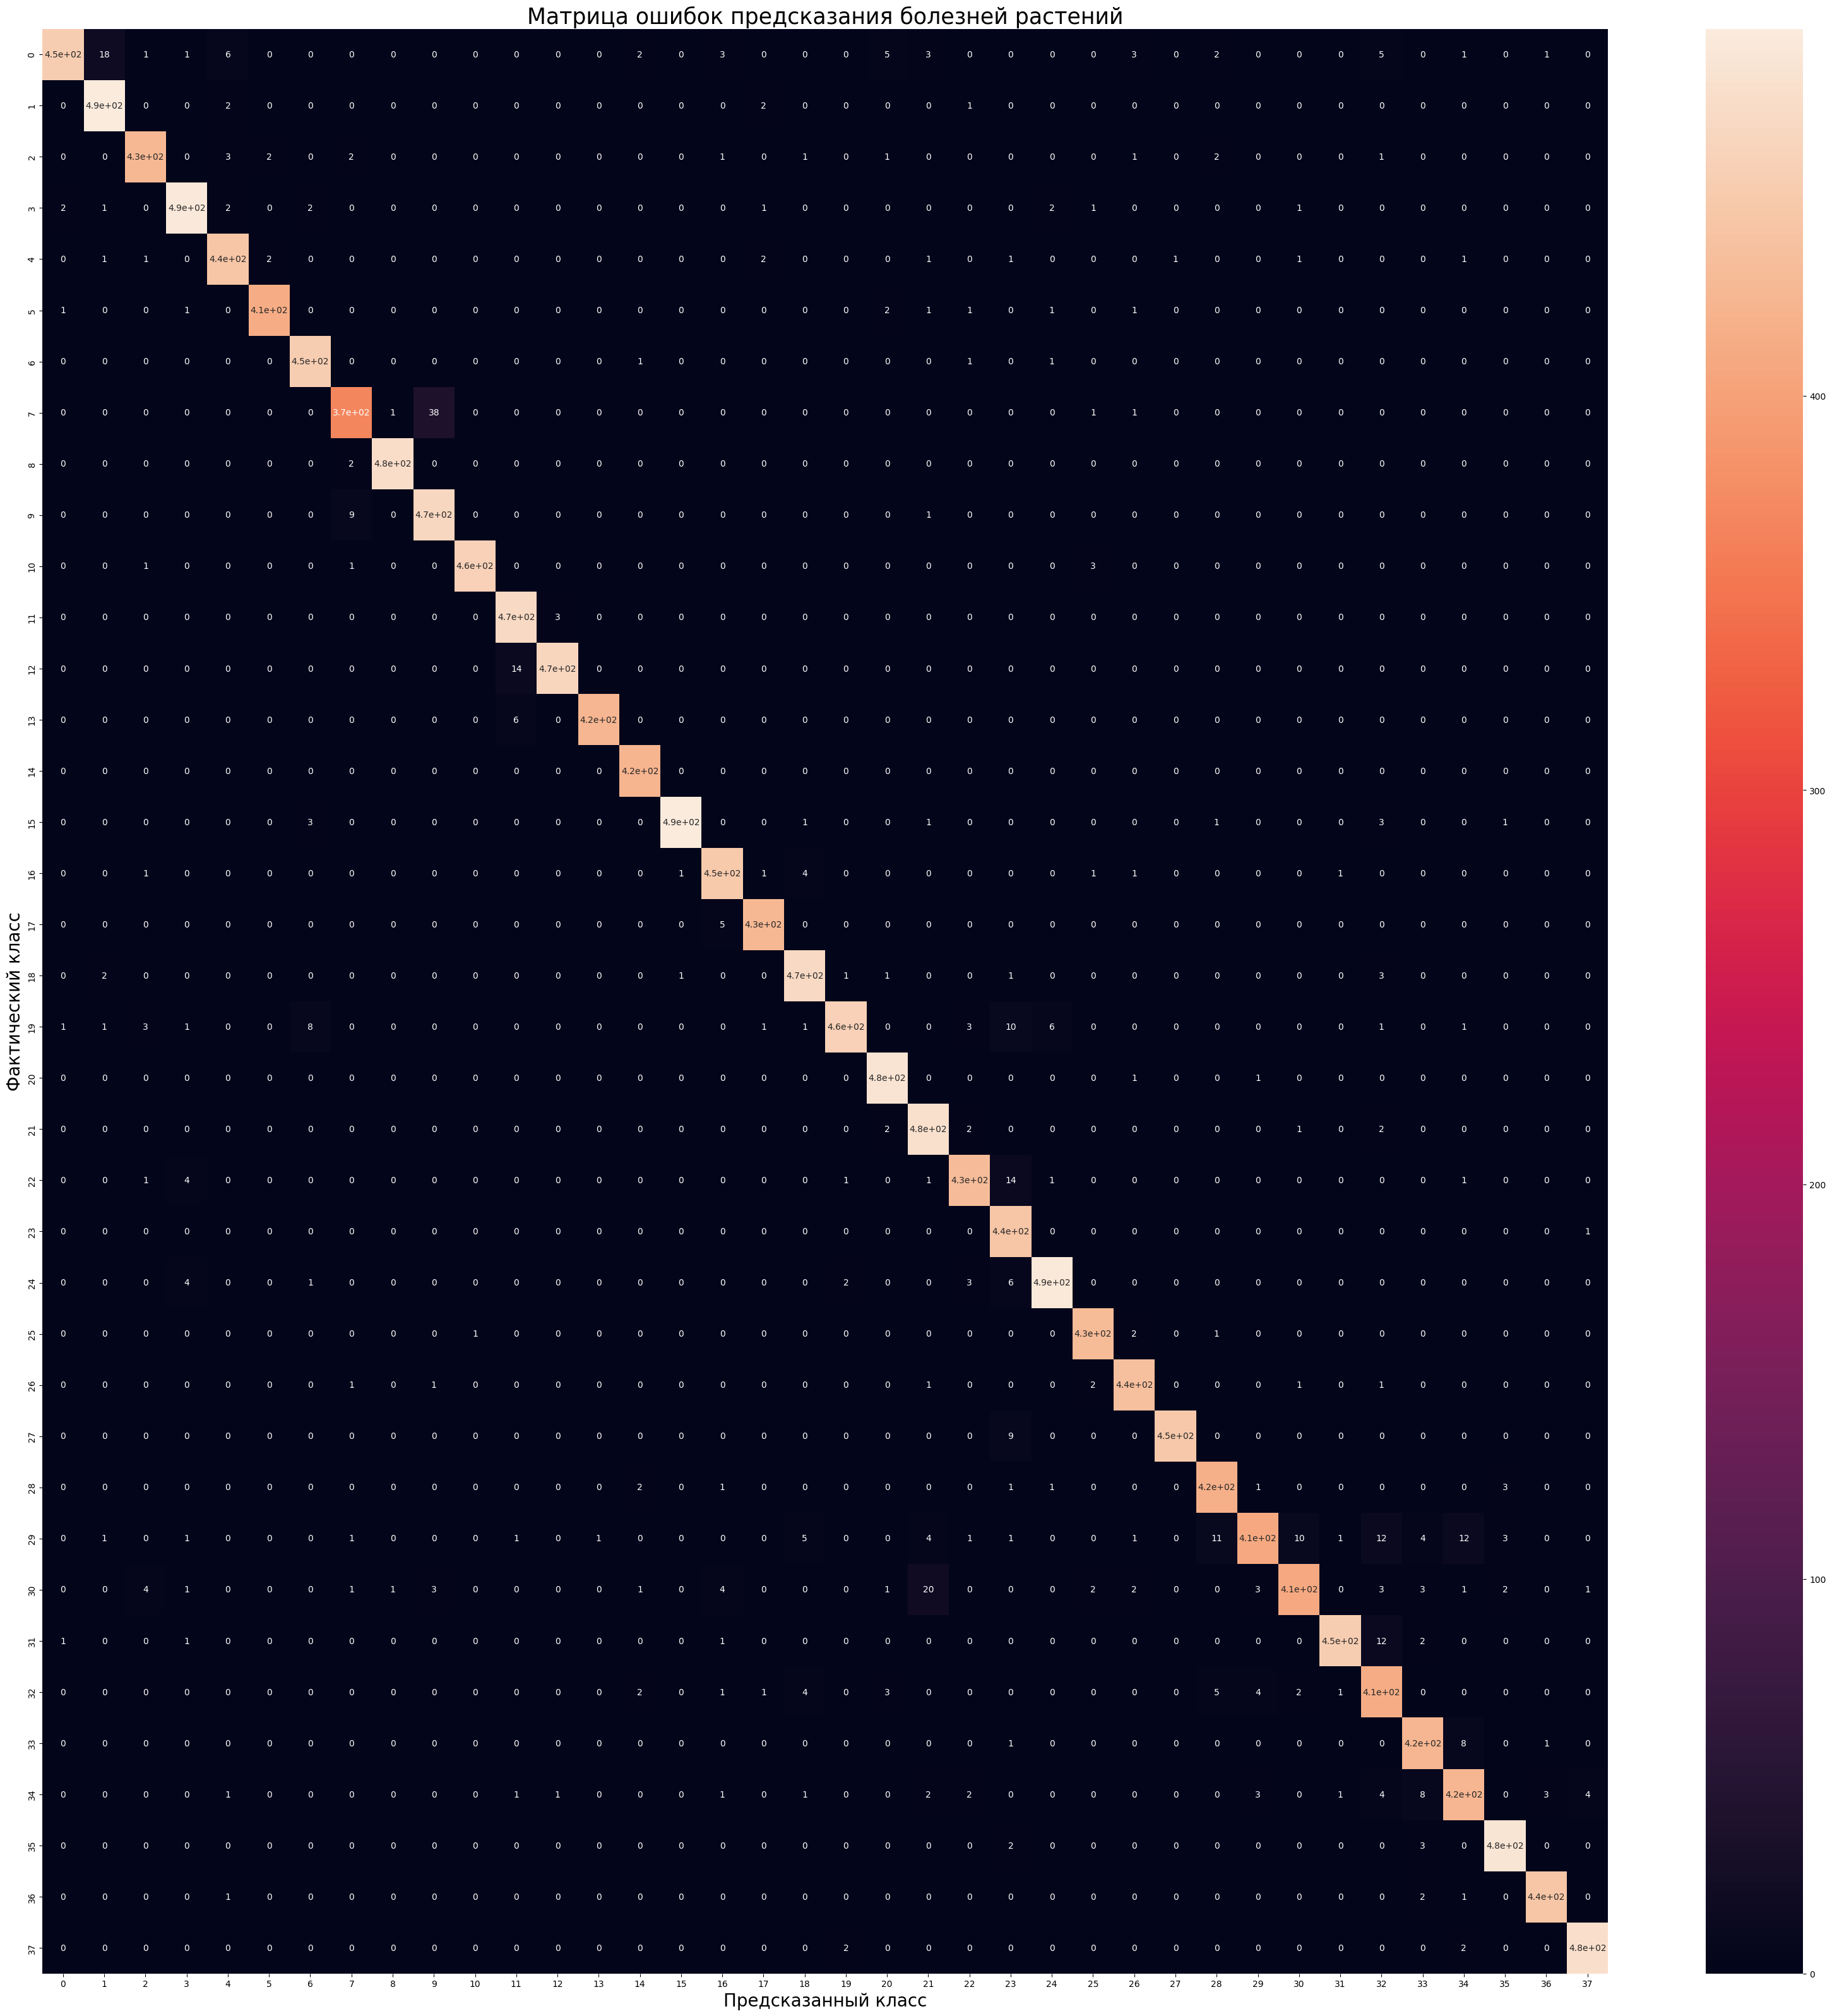

In [17]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Предсказанный класс",fontsize=20)
plt.ylabel("Фактический класс",fontsize=20)
plt.title("Матрица ошибок предсказания болезней растений",fontsize=25)
plt.show()